# Competition Evaluation: EEG Motor Imagery Classification on ds1a & ds1c
### CSP Feature Extraction + RBF-SVM Classification and Performance Comparison



# EEG Data Loading and Trial Extraction
## Overview

This section prepares the EEG dataset for further processing and classification.
The goal is to:

- Load the raw EEG .mat dataset

- Extract trials based on cue markers

- Convert labels into binary format

- Split the dataset into train and test sets

- Visualize a sample EEG trial

- Save processed data for later stages (filtering, CSP, classification)

The dataset used here is from the BCI Competition IV (dataset 1a).

## 1) Imports + Global Settings

**Goal:**  
Import required libraries and define global parameters:
- `cue_duration`: length of each trial in seconds (here 4s)
- `channels_plot`: which EEG channels to visualize in the sample plot


In [11]:
import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

cue_duration = 4.0
channels_plot = [0, 15, 30, 45, 58]

## 2) Function: Load the .mat file

Goal:
Load the raw MATLAB dataset and extract the main structures:

cnt: continuous EEG signal (samples × channels)

mrk: markers (trial positions + labels)

nfo: meta info (sampling frequency, channel names, etc.)

In [3]:
def load_mat(file_path: str):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Dataset not found")
    
    mat = scipy.io.loadmat(file_path, struct_as_record=False, squeeze_me=True)

    cnt = mat["cnt"]
    mrk = mat["mrk"]
    nfo = mat["nfo"]

    return cnt, mrk, nfo


## 3) Function: Extract trials from continuous EEG

Goal:
Convert the continuous EEG (cnt) into trial segments aligned to cue markers.

What this function does:

- Computes trial length in samples

- Reads trial start positions from mrk.pos

- Reads class labels from mrk.y

- Maps labels to binary 0/1 (supports {-1,1} or {1,2})

- Cuts segments of EEG data for each trial:

- Stacks all trials into:

In [4]:
def extract_trials(cnt: np.ndarray, mrk, fs: float, cue_duration: float):
    window_length = int(round(cue_duration * float(fs)))
    pos = np.array(mrk.pos, dtype=int).reshape(-1)
    y = np.array(mrk.y).reshape(-1)
    unique_labels = np.unique(y)

    # Mapping the labels to 0 and 1
    if set(unique_labels.tolist()) == {-1, 1}:
        y_mapped = (y == 1).astype(int)
        class_map = {-1: 0, 1: 1}
    elif set(unique_labels.tolist()) == {1, 2}:
        y_mapped = (y == 2).astype(int)
        class_map = {1: 0, 2: 1}
    else:
        y_mapped = y
        class_map = {int(k): int(k) for k in unique_labels}

    if cnt.ndim != 2:
        raise ValueError(f"Expected cnt to be 2D(samples, channels). Got shape {cnt.shape}")
    
    n_samples, n_channels = cnt.shape

    trials = []
    kept_labels = []

    for i, start in enumerate(pos):
        end = start + window_length
        if start < 0 or end > n_samples:
            continue
        seg = cnt[start:end, :]      # (samples, channels)
        trials.append(seg.T)         # (channels, samples)
        kept_labels.append(y_mapped[i])

    if not trials:
        raise RuntimeError("No trials were extracted, check your data format again")
    
    X = np.stack(trials, axis=0)  # trials, channels, samples
    y_out = np.array(kept_labels)

    return X, y_out, window_length, class_map


## 4) Function: Train/Test split

Goal:
Shuffle trial indices and split trials into train and test sets

In [5]:
def train_test_split(X: np.ndarray, y: np.ndarray, train_ratio: float = 0.75, seed: int = 42):
    rng = np.random.default_rng(seed)
    idx = np.arange(X.shape[0])
    rng.shuffle(idx)

    n_train = int(round(train_ratio * len(idx)))
    train_idx = idx[:n_train]
    test_idx = idx[n_train:]

    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]


## 5) Function: Plot one extracted trial (selected channels)

Goal:
Visualize EEG signal for a single trial to confirm extraction correctness.

In [6]:
def plot_sample(X: np.ndarray, fs: float, channels_plot: list[int], sample_index: int = 0):
    # X: (trials, channels, samples)
    x = X[sample_index]  # (channels, samples)
    n_ch, n_samp = x.shape
    t = np.arange(n_samp) / float(fs)

    plt.figure()
    for ch in channels_plot:  # <-- 0-based indices
        if ch < 0 or ch >= n_ch:
            continue
        plt.plot(t, x[ch], label=f"ch {ch}")

    plt.xlabel("Time(s)")
    plt.ylabel("Amplitude")
    plt.title(f"one trial (index {sample_index}) - selected channels")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 6) Main pipeline: Load → Extract → Split → Plot → Save

Goal:
Run the full preprocessing pipeline using the functions above:

- Load raw .mat file
- Read sampling frequency fs from nfo.fs
- Extract trials (X, y) for cue_duration seconds
- Split into train/test
- Plot one sample trial

Save everything into a .npz file for later stages (filtering, CSP, classification)

Output file:

data/processed/ds1a_extracted.npz

fs: 100.0
cnt shape: (190594, 59)
window_length (samples): 400
X shape: (200, 59, 400)
y shape: (200,)
class_map: {-1: 0, 1: 1}
Train shapes: (150, 59, 400) (150,)
Test shapes: (50, 59, 400) (50,)


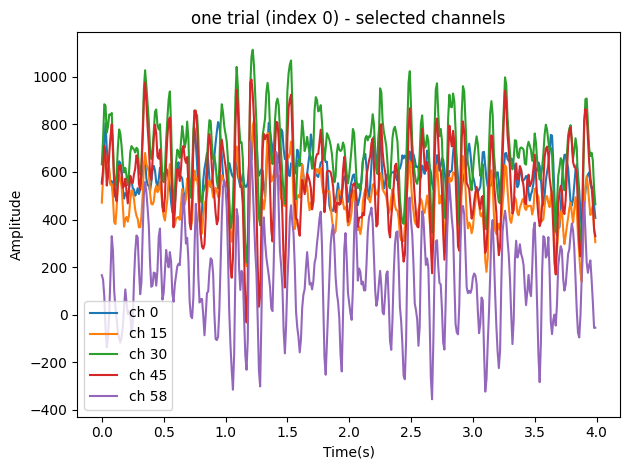

In [7]:
if __name__ == "__main__":
    file_path = os.path.join("data", "raw", "BCICIV_calib_ds1a.mat")
    cnt, mrk, nfo = load_mat(file_path)

    fs = float(nfo.fs)
    print("fs:", fs)
    print("cnt shape:", cnt.shape)

    X, y, window_length, class_map = extract_trials(cnt, mrk, fs, cue_duration)

    print("window_length (samples):", window_length)
    print("X shape:", X.shape)  # (trials, channels, samples)
    print("y shape:", y.shape)
    print("class_map:", class_map)

    X_train, y_train, X_test, y_test = train_test_split(X, y, train_ratio=0.75, seed=42)
    print("Train shapes:", X_train.shape, y_train.shape)
    print("Test shapes:", X_test.shape, y_test.shape)

    plot_sample(X_train, fs, channels_plot, sample_index=0)

    os.makedirs(os.path.join("data", "processed"), exist_ok=True)
    np.savez(
        os.path.join("data", "processed", "ds1a_extracted.npz"),
        X=X, y=y,
        X_train=X_train, y_train=y_train,
        X_test=X_test, y_test=y_test,
        fs=fs, window_length=window_length,
        class_map=class_map
    )


## Function: Bandpass filter for EEG trials

Goal:
Apply a Butterworth bandpass filter to EEG trials.

Input format

- X has shape: (trials, channels, samples)
- fs: sampling frequency (Hz)
- lowf, highf: cutoff frequencies (Hz)
- order: Butterworth filter order (default = 4)

### What this function does

Converts cutoff frequencies to normalized frequencies using Nyquist frequency:

nyq = fs/2

low = lowf/nyq, high = highf/nyq

Designs a bandpass Butterworth filter:

(b, a) = butter(order, [low, high], btype="bandpass")

Filters each channel of each trial using zero-phase filtering (filtfilt)

This avoids phase shift (important for EEG analysis)

Returns filtered array with the same shape as *x*

In [8]:
def bandpass_filter(X, fs, lowf, highf, order = 4):
    nyq = 0.5 * fs
    low = lowf / nyq
    high = highf / nyq

    b, a = butter(order, [low,high], btype = "bandpass")
    X_filt = np.zeros_like(X, dtype = np.float64)

    for i in range(X.shape[0]):
        for ch in range(X.shape[1]):
            X_filt[i, ch] = filtfilt(b, a, X[i, ch])

    return X_filt

## Main pipeline: Load extracted trials

Goal:
Load the extracted EEG trials from the previous preprocessing step.

Reads from:

- data/processed/ds1a_extracted.npz

Extracts:

- X: trial data (trials, channels, samples)

- y: labels (trials,)

- fs: sampling frequency

## Save filtered datasets for next steps

Goal:
Save the filtered signals into a new .npz file so the next step (CSP + classification) can load them directly.

### Writes to:

data/processed/ds1a_filtered_bands.npz

Contents saved:

- X_8_30: filtered 8–30 Hz trials

- X_mu: filtered 8–13 Hz trials

- X_beta: filtered 13–30 Hz trials

- y: labels

- fs: sampling frequency

In [16]:
def main():
    in_path = os.path.join("data", "processed", "ds1a_extracted.npz")
    out_path = os.path.join("data", "processed", "ds1a_filtered_bands.npz")

    data = np.load(in_path, allow_pickle = True)

    X = data["X"]
    y = data["y"]
    fs = float(data["fs"])
    print("Loaded dataset:", X.shape)
    
    np.savez(
        out_path,
        X_8_30 = X_8_30,
        X_mu = X_mu,
        X_beta = X_beta,
        y = y,
        fs = fs
    )

    print("Saved filtered datasets to:", out_path)

## Filtering: Create three frequency-band datasets

Goal:
Create and store three filtered versions of the same trials:

- 1.Full motor-imagery band (8–30 Hz)

- 2.Mu band (8–13 Hz)

- 3.Beta band (13–30 Hz)

These will be used later for CSP feature extraction and comparison between:

- Full-band approach (8–30)

- Split-band approach (mu + beta concatenation)

In [ ]:
print("Filtering 8-30 Hz...")
X_8_30 = bandpass_filter(X, fs, 8, 30)

print("Filering 8-13 Hz...")
X_mu = bandpass_filter(X, fs, 8, 13)

print("Filtering 13-30 Hz...")
X_beta = bandpass_filter(X, fs, 13, 30)

Filtering 8-30 Hz...
Filering 8-13 Hz...
Filtering 13-30 Hz...


## Run the pipeline

Goal:
Execute the main() function.

In [18]:
if __name__ == "__main__":
        main()

Loaded dataset: (200, 59, 400)
Saved filtered datasets to: data\processed\ds1a_filtered_bands.npz


## Load and Inspect the Extracted EEG Dataset

This cell loads the previously processed EEG dataset and checks its contents to ensure that trial extraction and saving were performed correctly.

The file being loaded:

In [20]:
data = np.load("data/processed/ds1a_extracted.npz")

print("Keys inside file:")
print(data.files)

print("\nX shape:", data["X"].shape)
print("y shape:", data["y"].shape)

print("\nTrain shape:", data["X_train"].shape)
print("Test shape:", data["X_test"].shape)


Keys inside file:
['X', 'y', 'X_train', 'y_train', 'X_test', 'y_test', 'fs', 'window_length', 'class_map']

X shape: (200, 59, 400)
y shape: (200,)

Train shape: (150, 59, 400)
Test shape: (50, 59, 400)


## Common Spatial Patterns (CSP)

Common Spatial Patterns (CSP) is a feature extraction technique widely used in EEG-based motor imagery classification. The main purpose of CSP is to transform multi-channel EEG signals into a new representation that highlights the differences between two mental states, such as imagining movement of the left hand versus the right hand.

### Why CSP is used
Raw EEG signals contain recordings from many electrodes and are highly noisy and complex. In motor imagery tasks, the most important information is not the exact waveform of the signal, but the **change in signal power (variance)** across different regions of the brain. These power changes occur mainly in specific frequency bands related to motor cortex activity.

CSP is used because it can automatically discover spatial patterns in the EEG that best separate the two classes. Instead of using all channels directly, CSP finds combinations of channels that make the difference between classes more visible and easier for machine learning algorithms to detect.

### How CSP works
Each EEG trial consists of multiple channels recorded over time. CSP analyzes the statistical structure of the signals by computing covariance matrices for each class. These covariance matrices represent how signal power is distributed across channels for each mental task.

CSP then finds spatial filters that transform the original EEG signals into new components. These filters are chosen so that:
- Some components have maximum variance for one class and minimum variance for the other
- Other components show the opposite behavior

After applying these spatial filters, the EEG data is projected into a new space where the difference between classes becomes stronger. The variance of each resulting component is calculated and used as a feature. Typically, the logarithm of the variance is used to stabilize the values and improve numerical performance.

### Philosophy behind CSP
The core idea behind CSP is that motor imagery does not simply change the shape of EEG signals, but rather changes the **distribution of signal power across the scalp**. By finding spatial filters that emphasize these power differences, CSP creates features that directly reflect how brain activity differs between tasks.

Instead of manually selecting important electrodes, CSP automatically learns the most informative spatial patterns from the data itself. This makes it a powerful and data-driven method for extracting meaningful features from EEG signals.

In summary, CSP is used in this project to transform raw EEG signals into a set of discriminative features that better represent the differences between motor imagery classes, making visualization and classification more effective.

## Mathematical Explanation of Common Spatial Patterns (CSP)

Common Spatial Patterns (CSP) is a spatial filtering technique used to extract discriminative features from multi-channel EEG signals by maximizing the variance difference between two classes.

### Signal Representation
Each EEG trial is represented as a matrix:

$$
X \in \mathbb{R}^{C \times T}
$$

where:
- $C$ = number of EEG channels  
- $T$ = number of time samples  

Each trial therefore contains signals from multiple electrodes over time.

---

### Covariance Matrices
For each trial, a spatial covariance matrix is computed:

$$
C = \frac{X X^T}{\text{trace}(X X^T)}
$$

This normalization makes the covariance independent of signal amplitude and improves stability.

For a two-class problem, the average covariance matrix for each class is:

$$
C_1 = \frac{1}{N_1} \sum_{i=1}^{N_1} C_i^{(1)}, \qquad
C_2 = \frac{1}{N_2} \sum_{i=1}^{N_2} C_i^{(2)}
$$

where:
- $C_1$ = mean covariance for class 1  
- $C_2$ = mean covariance for class 2  

The composite covariance matrix is:

$$
C = C_1 + C_2
$$

---

### Whitening Transformation
To simplify the optimization problem, the composite covariance matrix is whitened.

First compute eigen-decomposition:

$$
C = E \Lambda E^T
$$

where:
- $E$ = eigenvectors  
- $\Lambda$ = diagonal matrix of eigenvalues  

The whitening matrix is:

$$
P = \Lambda^{-1/2} E^T
$$

After whitening:

$$
P C P^T = I
$$

This means the covariance becomes identity in the transformed space.

---

### Eigenvalue Problem
After whitening, one class covariance becomes:

$$
S_1 = P C_1 P^T
$$

Since total covariance equals identity:

$$
S_1 + S_2 = I
$$

CSP solves:

$$
S_1 w = \lambda w
$$

The eigenvectors $w$ represent spatial filters and eigenvalues $\lambda$ show how well each filter separates the two classes.

- Large eigenvalues → maximize variance for class 1  
- Small eigenvalues → maximize variance for class 2  

---

### Spatial Filters
The final CSP spatial filter matrix is:

$$
W = B^T P
$$

where $B$ contains eigenvectors of the whitened covariance matrix.

Only the most discriminative filters are selected:
- Filters with largest eigenvalues  
- Filters with smallest eigenvalues  

---

### Feature Extraction
Each EEG trial is projected into CSP space:

$$
Z = W^T X
$$

The variance of each component is computed:

$$
f_i = \log(\text{var}(Z_i))
$$

These log-variance values form the final feature vector used for visualization and classification.

---

### Intuition Behind the Mathematics
CSP finds spatial directions in EEG data where one class has maximum variance and the other has minimum variance. By projecting signals onto these directions, the difference between motor imagery classes becomes clearer, allowing better visualization and classification.

# CSP Feature Extraction + t-SNE Visualization (8–30 vs Mu+Beta Concatenation)

This code loads the **bandpass-filtered EEG trials** (8–30 Hz, Mu 8–13 Hz, Beta 13–30 Hz), extracts **CSP log-variance features** for two different feature strategies, visualizes separability using **t-SNE**, and saves the extracted features for the next stage (classification).

---

## What this script produces (two parallel feature sets)

### A) Full-band CSP (8–30 Hz)
1. Fit CSP on **training trials only** from `X_8_30`
2. Transform train/test into CSP features  
**Output features:**
- `F_train`, `F_test`  → shape `(n_trials, 2*N_PAIRS)`

### B) Split-band CSP + Concatenation (Mu + Beta)
1. Fit CSP separately on **Mu** trials and **Beta** trials (train only)
2. Transform both bands into CSP features
3. Concatenate features: `[Mu_features, Beta_features]`  
**Output features:**
- `F_mubeta_train`, `F_mubeta_test` → shape `(n_trials, 4*N_PAIRS)`

With `N_PAIRS = 6`:
- Full-band features: `2*6 = 12`
- Mu+Beta concatenated features: `4*6 = 24`

---

## Step-by-step explanation of the code

### 1) Imports and global configuration
- Loads NumPy, Matplotlib and t-SNE
- Defines which band is used as the “full-band” for CSP (`BAND_KEY = "X_8_30"`)
- Sets CSP hyperparameters and random seed

In [22]:
from sklearn.manifold import TSNE

BAND_KEY = "X_8_30"

N_PAIRS = 6
REG = 1e-10
SEED = 42

Covariance computation (trace-normalized)

CSP relies on covariance matrices.
This code computes a trial covariance and normalizes it by its trace (sum of diagonal), which reduces sensitivity to overall trial power.

- cov_trace_norm(trial): computes trial @ trial.T and divides by trace

- mean_cov(X): averages normalized covariances over trials

In [23]:
def cov_trace_norm(trial):
    c = trial @ trial.T
    tr = np.trace(c)
    return c / tr if tr > 0 else c

def mean_cov(X):
    return np.mean([cov_trace_norm(tr) for tr in X], axis = 0)

Whitening transform

To compute CSP using a stable eigen-decomposition approach, the sum covariance is whitened:

- C = C0 + C1

- Compute eigen-decomposition of C

- Build whitening matrix P = D^{-1/2} * E^T

In [24]:
def whitener(C, eps = 1e-12):
    evals, evecs = np.linalg.eigh(C)
    evals = np.maximum(evals, eps)
    D_inv_sqrt = np.diag(1.0/np.sqrt(evals))
    P = D_inv_sqrt @ evecs.T
    return P

Fit CSP spatial filters

fit_csp(X, y) learns spatial filters that maximize variance for one class while minimizing it for the other.

Steps:

- 1.Split trials by class (X0, X1)

- 2.Compute regularized mean covariances C0, C1

- 3.Compute whitening matrix from C0 + C1

- 4.Transform C0 into whitened space and eigendecompose

- 5.Build full CSP projection matrix W_full

- 6.Select the most discriminative filters from both ends of eigen-spectrum:


In [25]:
def fit_csp(X, y, n_pairs = 4, reg = 1e-10):
    X0 = X[y == 0]
    X1 = X[y == 1]
    if len(X0) == 0 or len(X1) == 0:
        raise ValueError("Need trials from both classes to fit CSP")
    
    C0 = mean_cov(X0) + reg * np.eye(X.shape[1])
    C1 = mean_cov(X1) + reg * np.eye(X.shape[1])
    C = C0 + C1

    P = whitener(C)
    S0 = P @ C0 @ P.T

    evals, B = np.linalg.eigh(S0)

    idx = np.argsort(evals)
    B = B[:, idx]

    W_full = (B.T @ P)
    
    picks = np.r_[0:n_pairs, -n_pairs:0]
    W = W_full[picks, :].T

    return W

# Transform trials into CSP features (log-variance)

After learning CSP filters W, each trial is projected:

- Z = W.T @ X[i] (spatially filtered signals)

- Compute variance per component

- Take log to obtain robust features

In [26]:
def transform_csp(X, W):
    F = np.zeros((X.shape[0], W.shape[1]), dtype = np.float64)
    for i in range(X.shape[0]):
        Z = W.T  @ X[i]
        var = np.var(Z, axis = 1)
        F[i] = np.log(var + 1e-12)
    return F

# Split indices (train/test) to avoid leakage

Important: CSP is fitted only on training data.
The split is done using shuffled indices and a fixed seed.

In [27]:
def train_test_split_idx(n, train_ratio=0.75, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    n_train = int(round(train_ratio * n))
    return idx[:n_train], idx[n_train:]

# t-SNE utilities

Two helper functions:

- tsne_2d(features): maps features into 2D

- plot_tsne(Z, y, title): scatter plot colored by class

In [28]:
def tsne_2d(features, seed=42):
    return TSNE(
        n_components=2,
        random_state=seed,
        init="pca",
        learning_rate="auto"
    ).fit_transform(features)

def plot_tsne(Z, y, title):
    plt.figure()
    plt.scatter(Z[y == 0, 0], Z[y == 0, 1], alpha=0.7, label="class 0")
    plt.scatter(Z[y == 1, 0], Z[y == 1, 1], alpha=0.7, label="class 1")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Load filtered bands and split into train/test
Loads:
- X_8_30 (via BAND_KEY)
- X_mu, X_beta
- y

Then splits into train/test and creates corresponding subsets for all bands.

# t-SNE BEFORE CSP (baseline visualization)

Before CSP, the script computes a simple baseline feature:

- per-channel log-variance of the 8–30 Hz training trials
Then it applies t-SNE to visualize class separation.

# CSP on full band (8–30 Hz) + t-SNE

Fits CSP filters on X_train only, transforms both train and test, prints shapes, and visualizes train features with t-SNE.


CSP on Mu and Beta separately + concatenate + t-SNE

Fits CSP on Mu and Beta training data separately, extracts features for both sets, concatenates them, prints shapes, and visualizes with t-SNE.


In [31]:
def main():
    # Load filtered data
    in_path = os.path.join("data", "processed", "ds1a_filtered_bands.npz")
    d = np.load(in_path, allow_pickle=True)

    X = d[BAND_KEY]            
    X_mu = d["X_mu"]
    X_beta = d["X_beta"]
    y = d["y"].astype(int)     
    
    print("Loaded:", BAND_KEY, X.shape, "y:", y.shape)
    print("Loaded: X_mu", X_mu.shape, "X_beta", X_beta.shape)

    train_idx, test_idx = train_test_split_idx(len(y), train_ratio=0.75, seed=SEED)
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    X_mu_train = X_mu[train_idx]
    X_mu_test = X_mu[test_idx]
    X_beta_train = X_beta[train_idx]
    X_beta_test = X_beta[test_idx]
        # ---------------- t-SNE BEFORE CSP ----------------
    F_before = np.log(np.var(X_train, axis=2) + 1e-12)
    Z_before = tsne_2d(F_before, seed=SEED)
    plot_tsne(Z_before, y_train, f"t-SNE BEFORE CSP ({BAND_KEY}: per-channel log-variance)")
        # ---------------- CSP on 8-30  ----------------
    W = fit_csp(X_train, y_train, n_pairs=N_PAIRS, reg=REG)
    F_train = transform_csp(X_train, W)
    F_test = transform_csp(X_test, W)

    print("CSP 8-30 features:")
    print("F_train:", F_train.shape, "F_test:", F_test.shape)
        # ---------------- t-SNE AFTER CSP ----------------
    Z_after = tsne_2d(F_train, seed=SEED)
    plot_tsne(Z_after, y_train, f"t-SNE AFTER CSP ({BAND_KEY}: CSP log-variance features)")
        #----------------- CSP on mu and beta seperate + concatenate ---------
    W_mu = fit_csp(X_mu_train, y_train, n_pairs=N_PAIRS, reg=REG)
    W_beta = fit_csp(X_beta_train, y_train, n_pairs=N_PAIRS, reg=REG)

    F_mu_train = transform_csp(X_mu_train, W_mu)
    F_mu_test = transform_csp(X_mu_test, W_mu)

    F_beta_train = transform_csp(X_beta_train, W_beta)
    F_beta_test = transform_csp(X_beta_test, W_beta)

    F_mubeta_train = np.concatenate([F_mu_train, F_beta_train], axis=1)
    F_mubeta_test = np.concatenate([F_mu_test, F_beta_test], axis=1)

    print("CSP Mu+Beta concatenated features:")
    print("F_mubeta_train:", F_mubeta_train.shape, "F_mubeta_test:", F_mubeta_test.shape)

    Z_mubeta = tsne_2d(F_mubeta_train, seed=SEED)
    plot_tsne(Z_mubeta, y_train, "t-SNE AFTER CSP (Mu CSP + Beta CSP concatenated)")
        # Save CSP features for next step (classification)
    out_path = os.path.join("data", "processed", "ds1a_csp_features.npz")
    np.savez(
        out_path,
        band_key=BAND_KEY,
        train_idx=train_idx,
        test_idx=test_idx,
        y=y,
        F_train=F_train,
        y_train=y_train,
        F_test=F_test,
        y_test=y_test,
        F_mubeta_train=F_mubeta_train,
        F_mubeta_test=F_mubeta_test,
        n_pairs=N_PAIRS
    )
    print("Saved CSP features to:", out_path)
    

Loaded: X_8_30 (200, 59, 400) y: (200,)
Loaded: X_mu (200, 59, 400) X_beta (200, 59, 400)


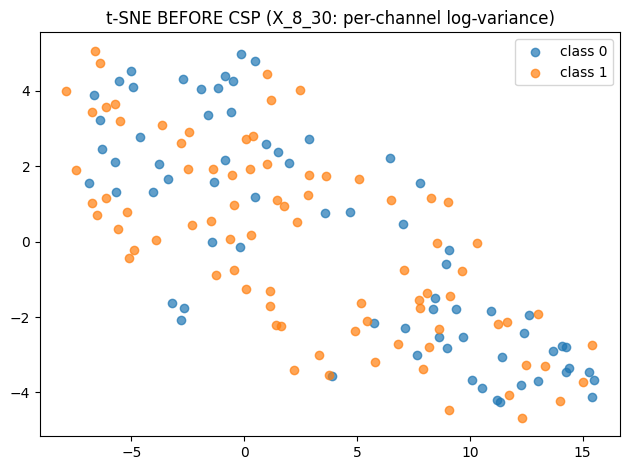

CSP 8-30 features:
F_train: (150, 12) F_test: (50, 12)


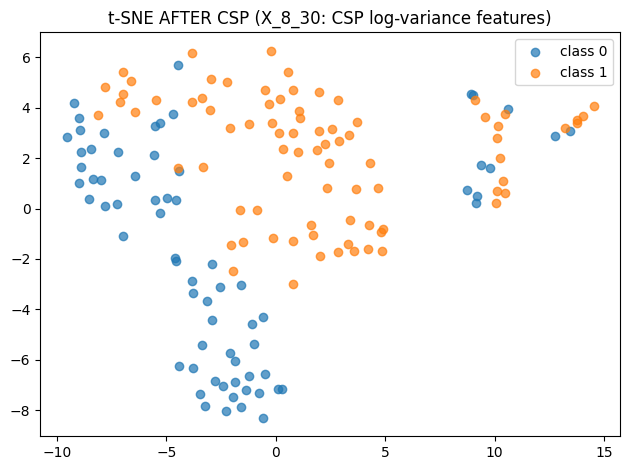

CSP Mu+Beta concatenated features:
F_mubeta_train: (150, 24) F_mubeta_test: (50, 24)


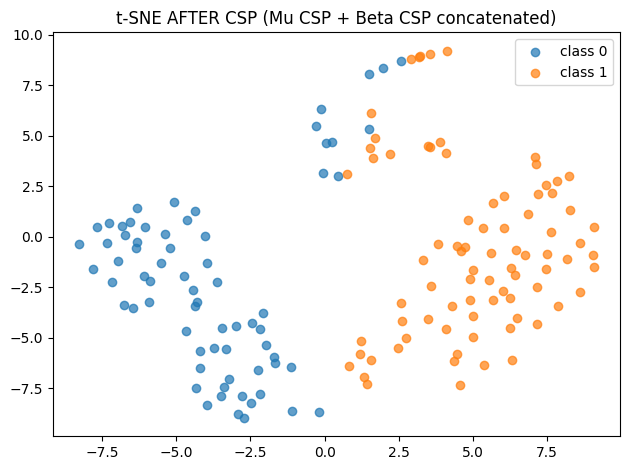

Saved CSP features to: data\processed\ds1a_csp_features.npz


In [32]:
if __name__ == "__main__":
    main()

# Kernel SVM (RBF) Classification + Full Evaluation (Custom vs scikit-learn)

This part of the project takes the **CSP features saved from the previous step** and performs **binary classification** using an **RBF-kernel SVM**.  
Everything is done for **both feature strategies**:

- **Branch A:** CSP features from **8–30 Hz** (`F_train`, `F_test`)
- **Branch B:** CSP features from **Mu + Beta concatenation** (`F_mubeta_train`, `F_mubeta_test`)

For each branch, we:
1. Standardize features (train-only fit)
2. Tune hyperparameters (`C`, `gamma`) on training data
3. Train an **RBF-SVM from scratch** (SMO)
4. Train an **RBF-SVM using scikit-learn** (SVC)
5. Evaluate and compare both models using:
   - Confusion matrix
   - ROC curve + AUC
   - Accuracy, Precision, Recall, F1
   - Classification report

---

## Part 1 — Imports and metrics tools

This section imports:
- typing/dataclasses utilities
- scikit-learn SVM (for comparison)
- evaluation metrics (confusion matrix, ROC/AUC, precision/recall/F1/accuracy)

In [33]:
from dataclasses import dataclass
from typing import Optional, Tuple, Dict
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    RocCurveDisplay,
    classification_report
)

# Part 2 — Feature Standardization (important for RBF-SVM)

RBF-SVM is highly sensitive to feature scale, so we apply z-score standardization:

- Fit mean/std only on training

- Transform both train and test with the same parameters

In [34]:
@dataclass
class Standardizer:
    mean_: Optional[np.ndarray] = None
    std_: Optional[np.ndarray] = None

    def fit(self, X: np.ndarray):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        return (X - self.mean_) / self.std_

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)

# Part 3 — RBF Kernel + Custom SVM Implementation (SMO)

This section contains the from-scratch implementation:

- rbf_kernel: computes the RBF kernel matrix

- SVMRBF_SM0: SVM trained using a simplified SMO optimizer

Important notes:

- Labels for the custom SVM must be in { -1, +1 }

- The model stores only support vectors after training

- decision_function() returns real-valued scores (used for ROC)

- predict() converts scores into class labels {0, 1}

In [35]:
def rbf_kernel(X1: np.ndarray, X2: np.ndarray, gamma: float) -> np.ndarray:
    # K(x,z) = exp(-gamma * ||x-z||^2)
    # Efficient pairwise squared distances:
    X1_sq = np.sum(X1 * X1, axis=1, keepdims=True)      # (n1,1)
    X2_sq = np.sum(X2 * X2, axis=1, keepdims=True).T    # (1,n2)
    dist2 = X1_sq + X2_sq - 2.0 * (X1 @ X2.T)
    return np.exp(-gamma * dist2)


# --------------------------
# SVM (RBF) from scratch using SMO
# Binary labels must be in {-1, +1}
# --------------------------
@dataclass
class SVMRBF_SM0:
    C: float = 1.0
    gamma: float = 0.1
    tol: float = 1e-3
    max_passes: int = 10
    max_iters: int = 20000
    seed: int = 42

    # learned params
    alphas_: Optional[np.ndarray] = None
    b_: float = 0.0
    X_sv_: Optional[np.ndarray] = None
    y_sv_: Optional[np.ndarray] = None
    alpha_sv_: Optional[np.ndarray] = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        rng = np.random.default_rng(self.seed)
        n = X.shape[0]
        y = y.astype(float)

        # precompute full kernel matrix
        K = rbf_kernel(X, X, self.gamma)

        alphas = np.zeros(n, dtype=float)
        b = 0.0

        def f(i):
            return np.sum(alphas * y * K[:, i]) + b

        passes = 0
        iters = 0

        while passes < self.max_passes and iters < self.max_iters:
            num_changed = 0
            for i in range(n):
                Ei = f(i) - y[i]

                # check KKT violation
                if (y[i] * Ei < -self.tol and alphas[i] < self.C) or (y[i] * Ei > self.tol and alphas[i] > 0):
                    # pick j != i randomly
                    j = i
                    while j == i:
                        j = rng.integers(0, n)
                    Ej = f(j) - y[j]

                    ai_old = alphas[i]
                    aj_old = alphas[j]

                    # bounds L, H
                    if y[i] != y[j]:
                        L = max(0.0, aj_old - ai_old)
                        H = min(self.C, self.C + aj_old - ai_old)
                    else:
                        L = max(0.0, ai_old + aj_old - self.C)
                        H = min(self.C, ai_old + aj_old)

                    if abs(H - L) < 1e-12:
                        continue

                    # eta = 2Kij - Kii - Kjj
                    eta = 2.0 * K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0:
                        continue

                    # update aj
                    aj_new = aj_old - (y[j] * (Ei - Ej)) / eta
                    # clip
                    aj_new = np.clip(aj_new, L, H)

                    if abs(aj_new - aj_old) < 1e-5:
                        continue

                    # update ai
                    ai_new = ai_old + y[i] * y[j] * (aj_old - aj_new)

                    # update b
                    b1 = b - Ei - y[i] * (ai_new - ai_old) * K[i, i] - y[j] * (aj_new - aj_old) * K[i, j]
                    b2 = b - Ej - y[i] * (ai_new - ai_old) * K[i, j] - y[j] * (aj_new - aj_old) * K[j, j]

                    # choose b
                    if 0 < ai_new < self.C:
                        b = b1
                    elif 0 < aj_new < self.C:
                        b = b2
                    else:
                        b = 0.5 * (b1 + b2)

                    alphas[i] = ai_new
                    alphas[j] = aj_new
                    num_changed += 1

                iters += 1
                if iters >= self.max_iters:
                    break

            if num_changed == 0:
                passes += 1
            else:
                passes = 0

        # keep support vectors
        sv_mask = alphas > 1e-8
        self.alphas_ = alphas
        self.b_ = b
        self.X_sv_ = X[sv_mask]
        self.y_sv_ = y[sv_mask]
        self.alpha_sv_ = alphas[sv_mask]
        return self

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        K = rbf_kernel(self.X_sv_, X, self.gamma)  # (n_sv, n)
        scores = (self.alpha_sv_ * self.y_sv_) @ K + self.b_
        return scores

    def predict(self, X: np.ndarray) -> np.ndarray:
        scores = self.decision_function(X)
        return (scores >= 0).astype(int)  # map to {0,1}


# Part 4 — Evaluation: metrics + confusion matrix + ROC/AUC plots

This section evaluates predictions using:

- accuracy, precision, recall, F1

- classification report

- confusion matrix plot

- ROC curve plot + AUC

It uses scores (decision function outputs) for ROC, which is the correct approach.

In [36]:
def evaluate_binary(y_true01: np.ndarray, y_pred01: np.ndarray, scores: np.ndarray, title_prefix: str):
    acc = accuracy_score(y_true01, y_pred01)
    prec = precision_score(y_true01, y_pred01, zero_division=0)
    rec = recall_score(y_true01, y_pred01, zero_division=0)
    f1 = f1_score(y_true01, y_pred01, zero_division=0)

    print(f"\n[{title_prefix}] Metrics")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1       : {f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true01, y_pred01, digits=4, zero_division=0))

    cm = confusion_matrix(y_true01, y_pred01)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{title_prefix} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    fpr, tpr, _ = roc_curve(y_true01, scores)
    roc_auc = auc(fpr, tpr)
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
    plt.title(f"{title_prefix} - ROC (AUC={roc_auc:.4f})")
    plt.tight_layout()
    plt.show()

    return {"acc": acc, "prec": prec, "rec": rec, "f1": f1, "auc": roc_auc}

# Part 5 — Hyperparameter tuning (train-only grid search)

This section selects the best C and gamma using a simple grid search:

It splits the training set internally into fit/validation

Trains the custom SVM on fit and evaluates on validation

Returns the best C, gamma

In [37]:
def simple_grid_search_custom_svm(
    Xtr: np.ndarray, ytr01: np.ndarray,
    C_list=(0.1, 1.0, 10.0, 100.0),
    gamma_list=(0.01, 0.1, 1.0, 10.0),
    seed=42
) -> Tuple[float, float, Dict]:
    # use a small internal split inside train for model selection (holdout)
    rng = np.random.default_rng(seed)
    idx = np.arange(len(ytr01))
    rng.shuffle(idx)
    split = int(round(0.8 * len(idx)))
    fit_idx, val_idx = idx[:split], idx[split:]

    X_fit, y_fit = Xtr[fit_idx], ytr01[fit_idx]
    X_val, y_val = Xtr[val_idx], ytr01[val_idx]

    y_fit_pm = np.where(y_fit == 1, 1.0, -1.0)

    best = {"acc": -1.0, "C": None, "gamma": None}
    for C in C_list:
        for gamma in gamma_list:
            model = SVMRBF_SM0(C=C, gamma=gamma, seed=seed, max_passes=10, max_iters=20000)
            model.fit(X_fit, y_fit_pm)
            val_scores = model.decision_function(X_val)
            val_pred = (val_scores >= 0).astype(int)
            acc = accuracy_score(y_val, val_pred)
            if acc > best["acc"]:
                best.update({"acc": acc, "C": C, "gamma": gamma})

    return best["C"], best["gamma"], best


# Part 6 — Run one branch (A or B): standardize → tune → train → compare → report

This function runs the complete pipeline for one feature set:

- 1.Standardize train/test

- 2.Tune C, gamma

- 3.Train custom SVM (SMO)

- 4.Train scikit-learn SVC with same C, gamma

- 5.Evaluate both with identical metrics and plots

- 6.Print a side-by-side summary

In [ ]:
def run_one_branch(name: str, X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray, y_test: np.ndarray):
    print("\n" + "=" * 80)
    print(f"BRANCH: {name}")
    print("=" * 80)

    # 1) Standardize (fit on train only)
    scaler = Standardizer()
    Xtr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)

    # 2) Hyperparam selection on train only (simple holdout inside train)
    C_best, gamma_best, best_info = simple_grid_search_custom_svm(Xtr, y_train, seed=42)
    print(f"\n[{name}] Best (custom grid): C={C_best}, gamma={gamma_best}, val_acc={best_info['acc']:.4f}")

    # 3) Train CUSTOM SVM from scratch on full train
    ytr_pm = np.where(y_train == 1, 1.0, -1.0)
    custom = SVMRBF_SM0(C=C_best, gamma=gamma_best, seed=42, max_passes=15, max_iters=50000)
    custom.fit(Xtr, ytr_pm)

    custom_scores = custom.decision_function(Xte)          # real-valued scores
    custom_pred = (custom_scores >= 0).astype(int)

    custom_metrics = evaluate_binary(y_test, custom_pred, custom_scores, f"{name} | Custom RBF-SVM (SMO)")

    # 4) Train sklearn SVC with SAME params and compare
    sk = SVC(kernel="rbf", C=C_best, gamma=gamma_best)
    sk.fit(Xtr, y_train)

    sk_scores = sk.decision_function(Xte)
    sk_pred = sk.predict(Xte).astype(int)

    sk_metrics = evaluate_binary(y_test, sk_pred, sk_scores, f"{name} | scikit-learn SVC(RBF)")

    # 5) Compare side-by-side summary
    print(f"\n[{name}] SUMMARY COMPARISON (Test)")
    for k in ["acc", "prec", "rec", "f1", "auc"]:
        print(f"{k.upper():>4} | custom={custom_metrics[k]:.4f}   sklearn={sk_metrics[k]:.4f}")

    return {
        "best_C": C_best,
        "best_gamma": gamma_best,
        "custom": custom_metrics,
        "sklearn": sk_metrics
    }


# Part 7 — Main: load saved CSP features and run both branches

This section loads:

- F_train, F_test, y_train, y_test (8–30 CSP features)

- F_mubeta_train, F_mubeta_test (Mu+Beta concatenated CSP features)

Then it runs classification for both branches:

- A) CSP on 8–30Hz

- B) CSP on Mu+Beta concat

Finally, it prints the final test accuracy comparison.

Loaded features:
  F_train: (150, 12) y_train: (150,)
  F_test : (50, 12) y_test : (50,)
  F_mb_train: (150, 24) F_mb_test: (50, 24)

BRANCH: A) CSP on 8-30Hz

[A) CSP on 8-30Hz] Best (custom grid): C=0.1, gamma=0.1, val_acc=0.9333

[A) CSP on 8-30Hz | Custom RBF-SVM (SMO)] Metrics
Accuracy : 0.8400
Precision: 0.7200
Recall   : 0.9474
F1       : 0.8182

Classification report:
              precision    recall  f1-score   support

           0     0.9600    0.7742    0.8571        31
           1     0.7200    0.9474    0.8182        19

    accuracy                         0.8400        50
   macro avg     0.8400    0.8608    0.8377        50
weighted avg     0.8688    0.8400    0.8423        50



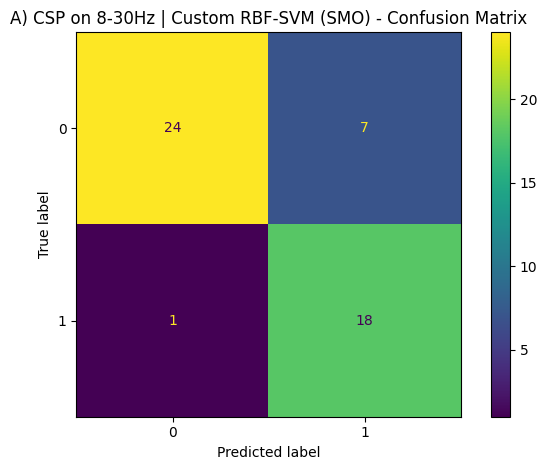

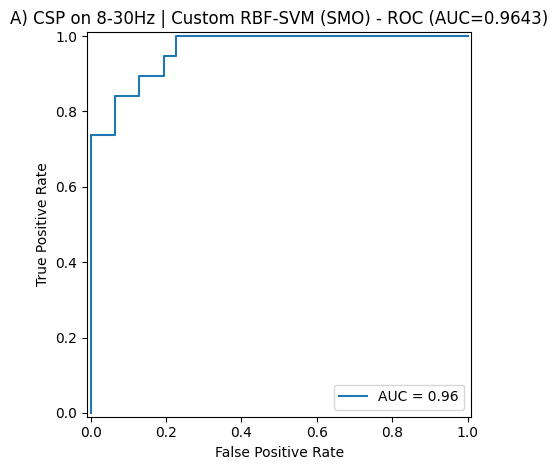


[A) CSP on 8-30Hz | scikit-learn SVC(RBF)] Metrics
Accuracy : 0.8400
Precision: 0.7200
Recall   : 0.9474
F1       : 0.8182

Classification report:
              precision    recall  f1-score   support

           0     0.9600    0.7742    0.8571        31
           1     0.7200    0.9474    0.8182        19

    accuracy                         0.8400        50
   macro avg     0.8400    0.8608    0.8377        50
weighted avg     0.8688    0.8400    0.8423        50



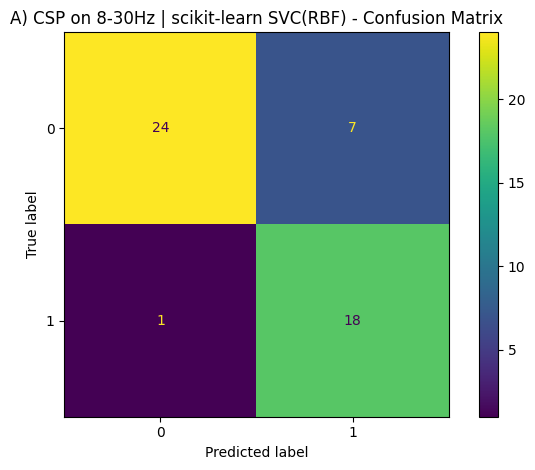

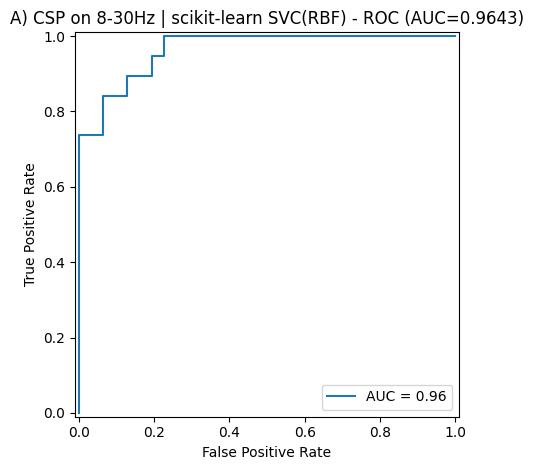


[A) CSP on 8-30Hz] SUMMARY COMPARISON (Test)
 ACC | custom=0.8400   sklearn=0.8400
PREC | custom=0.7200   sklearn=0.7200
 REC | custom=0.9474   sklearn=0.9474
  F1 | custom=0.8182   sklearn=0.8182
 AUC | custom=0.9643   sklearn=0.9643

BRANCH: B) CSP on (mu+beta) concat

[B) CSP on (mu+beta) concat] Best (custom grid): C=0.1, gamma=0.01, val_acc=1.0000

[B) CSP on (mu+beta) concat | Custom RBF-SVM (SMO)] Metrics
Accuracy : 0.8200
Precision: 0.6786
Recall   : 1.0000
F1       : 0.8085

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.7097    0.8302        31
           1     0.6786    1.0000    0.8085        19

    accuracy                         0.8200        50
   macro avg     0.8393    0.8548    0.8193        50
weighted avg     0.8779    0.8200    0.8220        50



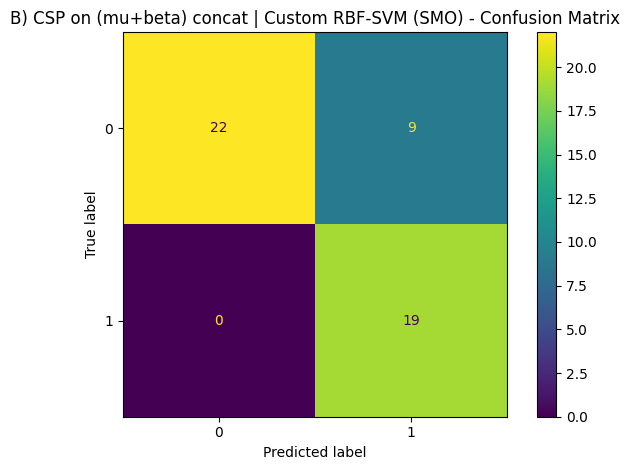

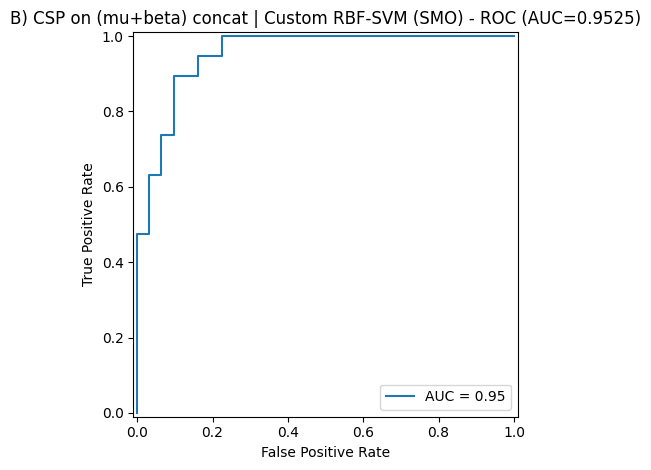


[B) CSP on (mu+beta) concat | scikit-learn SVC(RBF)] Metrics
Accuracy : 0.8400
Precision: 0.7037
Recall   : 1.0000
F1       : 0.8261

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.7419    0.8519        31
           1     0.7037    1.0000    0.8261        19

    accuracy                         0.8400        50
   macro avg     0.8519    0.8710    0.8390        50
weighted avg     0.8874    0.8400    0.8421        50



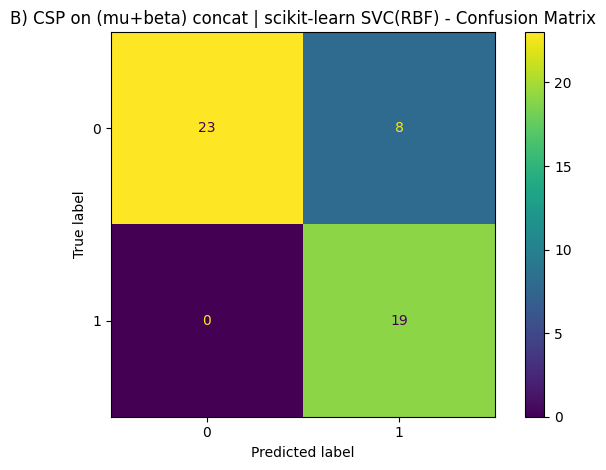

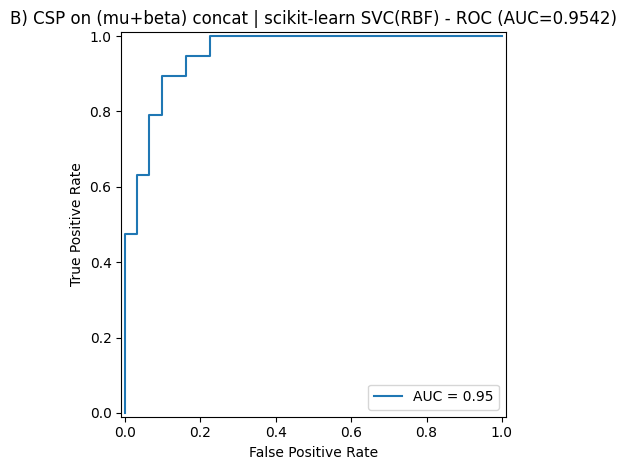


[B) CSP on (mu+beta) concat] SUMMARY COMPARISON (Test)
 ACC | custom=0.8200   sklearn=0.8400
PREC | custom=0.6786   sklearn=0.7037
 REC | custom=1.0000   sklearn=1.0000
  F1 | custom=0.8085   sklearn=0.8261
 AUC | custom=0.9525   sklearn=0.9542

################################################################################
FINAL RESULT (Test) - both branches
################################################################################
A) 8-30Hz  : custom acc=0.8400, sklearn acc=0.8400
B) mu+beta : custom acc=0.8200, sklearn acc=0.8400
################################################################################


In [38]:
def main():
    # load your saved features
    path = os.path.join("data", "processed", "ds1a_csp_features.npz")
    d = np.load(path, allow_pickle=True)

    # A) 8-30 CSP features
    F_train = d["F_train"]
    y_train = d["y_train"].astype(int)
    F_test = d["F_test"]
    y_test = d["y_test"].astype(int)

    # B) mu+beta concatenated CSP features
    F_mb_train = d["F_mubeta_train"]
    F_mb_test = d["F_mubeta_test"]

    print("Loaded features:")
    print("  F_train:", F_train.shape, "y_train:", y_train.shape)
    print("  F_test :", F_test.shape, "y_test :", y_test.shape)
    print("  F_mb_train:", F_mb_train.shape, "F_mb_test:", F_mb_test.shape)

    # Run BOTH branches exactly as you asked
    res_A = run_one_branch("A) CSP on 8-30Hz", F_train, y_train, F_test, y_test)
    res_B = run_one_branch("B) CSP on (mu+beta) concat", F_mb_train, y_train, F_mb_test, y_test)

    print("\n" + "#" * 80)
    print("FINAL RESULT (Test) - both branches")
    print("#" * 80)
    print("A) 8-30Hz  : custom acc={:.4f}, sklearn acc={:.4f}".format(res_A["custom"]["acc"], res_A["sklearn"]["acc"]))
    print("B) mu+beta : custom acc={:.4f}, sklearn acc={:.4f}".format(res_B["custom"]["acc"], res_B["sklearn"]["acc"]))
    print("#" * 80)


if __name__ == "__main__":
    main()


# Baseline Classification on CSP Features (LDA, Logistic Regression, Random Forest)

This script evaluates **three standard classifiers** on the CSP features you extracted earlier and saved in:

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42

# Part 2 — Evaluation helper function

This function:

1. Fits a given model on training data

2. Predicts test labels

3. Computes and prints:

- Accuracy

- Confusion matrix

- Classification report (precision/recall/F1 per class)

It provides a consistent evaluation format for all classifiers.

In [40]:
def evaluate(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=4))

# Part 3 — Run a group of models on one feature set

This function runs three different classifiers on one feature set and prints results.

Models used

1. LDA (Linear Discriminant Analysis)
A classic and very common baseline for CSP features in EEG/BCI.

2. Logistic Regression (with StandardScaler)
A linear classifier; scaling is included using a pipeline.

3. Random Forest
A non-linear ensemble method, useful as another baseline.

In [41]:
def run_one_feature_set(title, X_train, y_train, X_test, y_test):
    print("\n" + "=" * 60)
    print(title)
    print("Train:", X_train.shape, "Test:", X_test.shape)

    lda = LinearDiscriminantAnalysis()

    logreg = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, solver="lbfgs"))
    ])

    rf = RandomForestClassifier(n_estimators=300, random_state=SEED)

    evaluate("LDA", lda, X_train, y_train, X_test, y_test)
    evaluate("Logistic Regression", logreg, X_train, y_train, X_test, y_test)
    evaluate("Random Forest", rf, X_train, y_train, X_test, y_test)

# Part 4 — Main: Load saved CSP features and evaluate both strategies

This section loads the .npz feature file created in the CSP step and extracts:

- Labels: y_train, y_test

- Feature set A: F_train, F_test

- Feature set B: F_mubeta_train, F_mubeta_test

Then it calls run_one_feature_set() twice:

- Once for 8–30 Hz CSP

- Once for Mu+Beta concatenated CSP

In [42]:
def main():
    path = os.path.join("data", "processed", "ds1a_csp_features.npz")
    d = np.load(path, allow_pickle=True)

    y_train = d["y_train"].astype(int)
    y_test = d["y_test"].astype(int)

    F_train = d["F_train"]
    F_test = d["F_test"]

    F_mubeta_train = d["F_mubeta_train"]
    F_mubeta_test = d["F_mubeta_test"]

    run_one_feature_set("Feature set A: CSP on 8-30 Hz", F_train, y_train, F_test, y_test)
    run_one_feature_set("Feature set B: CSP on Mu + CSP on Beta (concatenated)", F_mubeta_train, y_train, F_mubeta_test, y_test)

# Part 5 — Run the script

This runs the pipeline when the file is executed as a script.

In [43]:
if __name__ == "__main__":
    main()


Feature set A: CSP on 8-30 Hz
Train: (150, 12) Test: (50, 12)

LDA
Accuracy: 0.92
Confusion matrix:
 [[29  2]
 [ 2 17]]
              precision    recall  f1-score   support

           0     0.9355    0.9355    0.9355        31
           1     0.8947    0.8947    0.8947        19

    accuracy                         0.9200        50
   macro avg     0.9151    0.9151    0.9151        50
weighted avg     0.9200    0.9200    0.9200        50


Logistic Regression
Accuracy: 0.88
Confusion matrix:
 [[27  4]
 [ 2 17]]
              precision    recall  f1-score   support

           0     0.9310    0.8710    0.9000        31
           1     0.8095    0.8947    0.8500        19

    accuracy                         0.8800        50
   macro avg     0.8703    0.8829    0.8750        50
weighted avg     0.8849    0.8800    0.8810        50


Random Forest
Accuracy: 0.9
Confusion matrix:
 [[27  4]
 [ 1 18]]
              precision    recall  f1-score   support

           0     0.9643    0.

# Unsupervised Clustering on CSP Features (K-Means from Scratch + PCA Visualization)

This script performs **unsupervised clustering** on the CSP feature vectors extracted earlier (saved in `ds1a_csp_features.npz`).  
It applies a **K-Means implementation from scratch** (including **k-means++ initialization**) and evaluates different numbers of clusters using:

- **WCSS / Inertia (Elbow method)**
- **Silhouette Score**

After selecting the best `k` (based on the maximum silhouette score), it visualizes the resulting clusters in **2D** using a simple **PCA (from scratch)** projection.

The same pipeline is run on both CSP feature strategies:

- **Feature set A:** CSP on **8–30 Hz** (`F_train`)
- **Feature set B:** **Mu CSP + Beta CSP concatenated** (`F_mubeta_train`)

---

## Part 1 — Imports and configuration

This section imports required libraries and sets a fixed random seed for reproducibility.

In [44]:
import os
import numpy as np
import matplotlib.pyplot as plt

SEED = 42


# Part 2 — Preprocessing + PCA (2D projection)

Before clustering, features are standardized (z-score) so that K-Means is not dominated by features with larger scale.

Then a lightweight PCA (2D) implementation is used only for visualization:

center the data

compute covariance

take the top-2 eigenvectors

project into 2D

In [45]:
def standardize(X):
    mu = X.mean(axis=0, keepdims=True)
    sigma = X.std(axis=0, keepdims=True)
    sigma = np.where(sigma == 0, 1.0, sigma)
    return (X - mu) / sigma

def pca_2d(X):
    Xc = X - X.mean(axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(1, (Xc.shape[0] - 1))
    evals, evecs = np.linalg.eigh(C)
    idx = np.argsort(evals)[::-1]
    W = evecs[:, idx[:2]]
    return Xc @ W

# Part 3 — K-Means from scratch (k-means++ + iterative updates)

This section implements K-Means without scikit-learn:

Key components

- k-means++ initialization (init_centroids_kmeanspp) for better starting points

- assignment step (assign_labels) based on nearest centroid (squared Euclidean distance)

- update step (recompute_centroids) by averaging points in each cluster

- supports multiple random restarts (n_init) and keeps the best run by lowest inertia

In [46]:
def init_centroids_kmeanspp(X, k, rng):
    n = X.shape[0]
    centroids = np.empty((k, X.shape[1]), dtype=np.float64)
    i0 = rng.integers(0, n)
    centroids[0] = X[i0]
    d2 = np.sum((X - centroids[0]) ** 2, axis=1)
    for i in range(1, k):
        probs = d2 / np.sum(d2)
        ci = rng.choice(n, p=probs)
        centroids[i] = X[ci]
        new_d2 = np.sum((X - centroids[i]) ** 2, axis=1)
        d2 = np.minimum(d2, new_d2)
    return centroids

def assign_labels(X, centroids):
    dists = np.sum((X[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
    return np.argmin(dists, axis=1), dists

def recompute_centroids(X, labels, k, rng):
    d = X.shape[1]
    centroids = np.empty((k, d), dtype=np.float64)
    for c in range(k):
        mask = (labels == c)
        if np.any(mask):
            centroids[c] = X[mask].mean(axis=0)
        else:
            centroids[c] = X[rng.integers(0, X.shape[0])]
    return centroids

def kmeans_fit(X, k, n_init=10, max_iter=300, tol=1e-6, seed=42):
    rng_master = np.random.default_rng(seed)
    best_inertia = np.inf
    best_labels = None
    best_centroids = None

    for _ in range(n_init):
        rng = np.random.default_rng(rng_master.integers(0, 2**32 - 1))
        centroids = init_centroids_kmeanspp(X, k, rng)

        prev_inertia = np.inf
        for _ in range(max_iter):
            labels, dists = assign_labels(X, centroids)
            inertia = float(np.sum(dists[np.arange(X.shape[0]), labels]))
            centroids_new = recompute_centroids(X, labels, k, rng)

            if abs(prev_inertia - inertia) <= tol * max(1.0, prev_inertia):
                centroids = centroids_new
                break
            prev_inertia = inertia
            centroids = centroids_new

        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.copy()
            best_centroids = centroids.copy()

    return best_labels, best_centroids, best_inertia

# Part 4 — Cluster quality metrics: Silhouette score

This section computes the silhouette score from scratch using pairwise distances:

- a(i): average distance to points in the same cluster

- b(i): smallest average distance to points in any other cluster

- silhouette for each point: (b-a)/max(a,b)

- final score is the mean over all points

This is used to select the best number of clusters k.

In [47]:
def silhouette_score_numpy(X, labels):
    n = X.shape[0]
    uniq = np.unique(labels)
    if uniq.size < 2:
        return np.nan

    D = np.sqrt(np.maximum(0.0, np.sum((X[:, None, :] - X[None, :, :]) ** 2, axis=2)))

    s = np.zeros(n, dtype=np.float64)
    for i in range(n):
        ci = labels[i]
        same = (labels == ci)
        same_count = int(np.sum(same))
        if same_count <= 1:
            s[i] = 0.0
            continue

        a = np.sum(D[i, same]) / (same_count - 1)

        b = np.inf
        for cj in uniq:
            if cj == ci:
                continue
            other = (labels == cj)
            b = min(b, np.mean(D[i, other]))

        denom = max(a, b)
        s[i] = (b - a) / denom if denom > 0 else 0.0

    return float(np.mean(s))


# Part 5 — Plotting utilities (Elbow, Silhouette, Cluster visualization)

This section provides plotting functions to:

- plot WCSS vs k (Elbow curve)

- plot Silhouette vs k

- visualize final clusters after projecting features into PCA 2D

In [48]:
def plot_wcss(k_values, wcss, title):
    plt.figure()
    plt.plot(k_values, wcss, marker="o")
    plt.xlabel("k")
    plt.ylabel("WCSS")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_silhouette(k_values, sil, title):
    plt.figure()
    plt.plot(k_values, sil, marker="o")
    plt.xlabel("k")
    plt.ylabel("Silhouette score")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_clusters_2d(Z, labels, title):
    plt.figure()
    for c in np.unique(labels):
        plt.scatter(Z[labels == c, 0], Z[labels == c, 1], alpha=0.7, label=f"cluster {c}")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Part 6 — Run K-Means analysis for one feature set

This function runs the full unsupervised pipeline for one input feature matrix:

1. Standardize features

2. Try multiple k values (default 2 to 10)

3. For each k:

- run K-Means

- compute inertia (WCSS)

- compute silhouette score

4. Plot elbow and silhouette curves

5. Select the best k by highest silhouette

6. Re-run K-Means with more restarts for the chosen k

7. Project to PCA 2D and plot clusters

In [49]:
def run_kmeans_section(X_features, name, k_min=2, k_max=10):
    Xs = standardize(X_features.astype(np.float64))

    k_values = np.arange(k_min, k_max + 1)
    wcss = []
    sil = []

    for k in k_values:
        labels, centroids, inertia = kmeans_fit(Xs, int(k), n_init=10, max_iter=300, tol=1e-6, seed=SEED)
        wcss.append(inertia)
        sil.append(silhouette_score_numpy(Xs, labels))

    wcss = np.array(wcss, dtype=np.float64)
    sil = np.array(sil, dtype=np.float64)

    plot_wcss(k_values, wcss, f"WCSS (Elbow) - {name}")
    plot_silhouette(k_values, sil, f"Silhouette score - {name}")

    k_best = int(k_values[np.nanargmax(sil)])
    print(f"\n{name} -> best k by silhouette: {k_best}")

    labels_best, _, _ = kmeans_fit(Xs, k_best, n_init=20, max_iter=500, tol=1e-7, seed=SEED)

    Z = pca_2d(Xs)
    plot_clusters_2d(Z, labels_best, f"K-Means clusters on PCA 2D (k={k_best}) - {name}")


# Part 7 — Main: load CSP features and run both strategies (A and B)

This section loads the saved CSP feature file and runs K-Means analysis on:

- F_train (Feature set A: 8–30 Hz CSP)

- F_mubeta_train (Feature set B: Mu+Beta concatenated CSP)

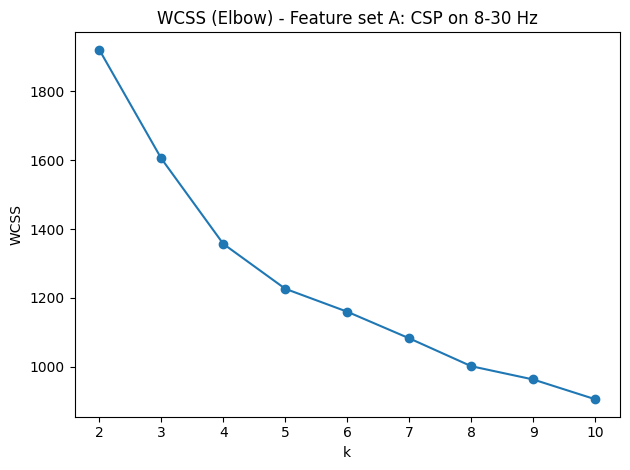

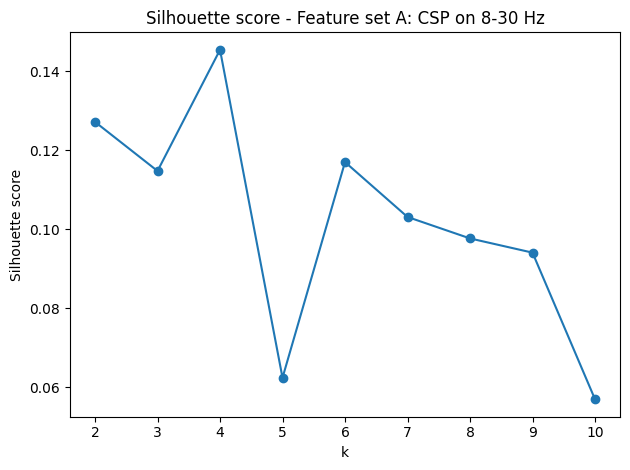


Feature set A: CSP on 8-30 Hz -> best k by silhouette: 4


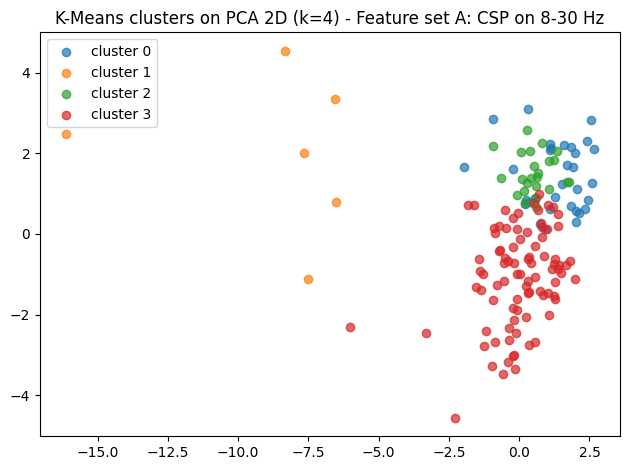

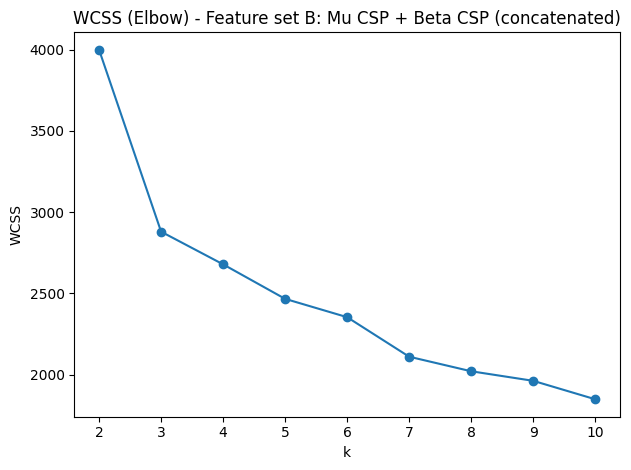

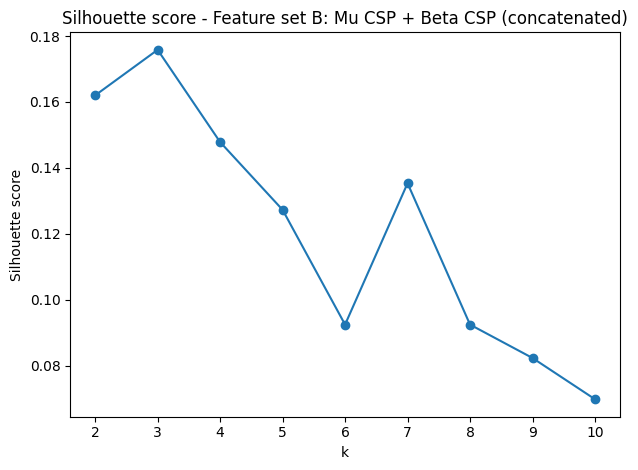


Feature set B: Mu CSP + Beta CSP (concatenated) -> best k by silhouette: 3


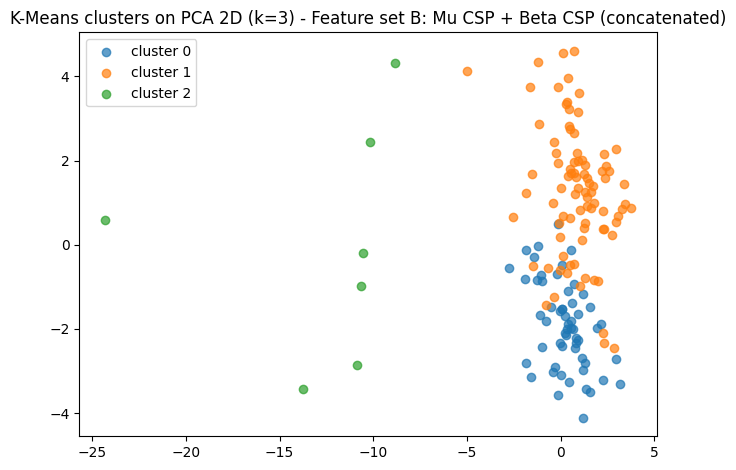

In [50]:
def main():
    path = os.path.join("data", "processed", "ds1a_csp_features.npz")
    d = np.load(path, allow_pickle=True)

    F_train = d["F_train"]
    F_mubeta_train = d["F_mubeta_train"]

    run_kmeans_section(F_train, "Feature set A: CSP on 8-30 Hz", k_min=2, k_max=10)
    run_kmeans_section(F_mubeta_train, "Feature set B: Mu CSP + Beta CSP (concatenated)", k_min=2, k_max=10)

if __name__ == "__main__":
    main()

# Competition Metric: Run the Pipeline on ds1a AND ds1c + Compare Results

In this section, we evaluate the same EEG pipeline on two calibration files:
- `BCICIV_calib_ds1a.mat`
- `BCICIV_calib_ds1c.mat`

For each file we run the full pipeline:
1. Load `.mat` file (cnt/mrk/nfo)
2. Extract 4-second trials based on markers
3. Bandpass filtering:
   - 8–30 Hz (full band)
   - 8–13 Hz (mu band)
   - 13–30 Hz (beta band)
4. CSP feature extraction (two feature strategies):
   - **A)** CSP on 8–30 Hz
   - **B)** CSP on mu + CSP on beta, then concatenate
5. Classification with **Kernel SVM (RBF)**
6. Report accuracy for each dataset and compare ds1a vs ds1c
7. Compute the average accuracy across both files (competition metric)

In [53]:
import os
import numpy as np
import scipy.io

from scipy.signal import butter, filtfilt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt

SEED = 42
CUE_DURATION = 4.0
REG = 1e-10
N_PAIRS = 6

## 1) Load `.mat` file and extract trials

We load the continuous EEG (`cnt`), markers (`mrk`), and metadata (`nfo`), then extract trials:
- Each trial starts at `mrk.pos[i]`
- Length is `CUE_DURATION * fs` samples
- Output format is:
  - `X`: (trials, channels, samples)
  - `y`: (trials,)

In [54]:
def load_mat(file_path: str):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Dataset not found: {file_path}")
    mat = scipy.io.loadmat(file_path, struct_as_record=False, squeeze_me=True)
    return mat["cnt"], mat["mrk"], mat["nfo"]

def extract_trials(cnt: np.ndarray, mrk, fs: float, cue_duration: float):
    window_length = int(round(cue_duration * float(fs)))
    pos = np.array(mrk.pos, dtype=int).reshape(-1)
    y = np.array(mrk.y).reshape(-1)
    unique_labels = np.unique(y)

    # Map labels to {0,1}
    if set(unique_labels.tolist()) == {-1, 1}:
        y_mapped = (y == 1).astype(int)
    elif set(unique_labels.tolist()) == {1, 2}:
        y_mapped = (y == 2).astype(int)
    else:
        # fallback (already binary or unusual)
        y_mapped = y.astype(int)

    if cnt.ndim != 2:
        raise ValueError(f"Expected cnt to be 2D(samples, channels). Got shape {cnt.shape}")

    n_samples, _ = cnt.shape
    trials, labels = [], []

    for i, start in enumerate(pos):
        end = start + window_length
        if start < 0 or end > n_samples:
            continue
        seg = cnt[start:end, :]   # (samples, channels)
        trials.append(seg.T)      # (channels, samples)
        labels.append(y_mapped[i])

    if not trials:
        raise RuntimeError("No trials extracted. Check marker positions or cue duration.")

    X = np.stack(trials, axis=0)  # (trials, channels, samples)
    y_out = np.array(labels, dtype=int)
    return X, y_out, window_length

## 2) Bandpass filtering (8–30, mu, beta)

We filter the extracted trials into:
- **X_8_30**: 8–30 Hz
- **X_mu**: 8–13 Hz
- **X_beta**: 13–30 Hz

These three arrays are needed because we will compare:
- Full-band CSP features (8–30)
- Concatenated CSP features (mu + beta)

In [56]:
def bandpass_filter(X, fs, lowf, highf, order=4):
    nyq = 0.5 * fs
    low = lowf / nyq
    high = highf / nyq
    b, a = butter(order, [low, high], btype="bandpass")

    X_filt = np.zeros_like(X, dtype=np.float64)
    for i in range(X.shape[0]):
        for ch in range(X.shape[1]):
            X_filt[i, ch] = filtfilt(b, a, X[i, ch])
    return X_filt

def make_bands(X, fs):
    X_8_30 = bandpass_filter(X, fs, 8, 30)
    X_mu   = bandpass_filter(X, fs, 8, 13)
    X_beta = bandpass_filter(X, fs, 13, 30)
    return X_8_30, X_mu, X_beta

## 3) CSP (two-class) feature extraction

We compute CSP filters using training folds only and convert each trial into a feature vector:
- Project trial: `Z = Wᵀ X`
- Feature: `log(var(Z))`

We will build two feature sets:
- **A)** CSP on 8–30 Hz
- **B)** CSP on mu and beta separately, then concatenate features

In [57]:
def cov_trace_norm(trial):
    c = trial @ trial.T
    tr = np.trace(c)
    return c / tr if tr > 0 else c

def mean_cov(X):
    return np.mean([cov_trace_norm(tr) for tr in X], axis=0)

def whitener(C, eps=1e-12):
    evals, evecs = np.linalg.eigh(C)
    evals = np.maximum(evals, eps)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(evals))
    return D_inv_sqrt @ evecs.T

def fit_csp(X, y, n_pairs=6, reg=1e-10):
    X0 = X[y == 0]
    X1 = X[y == 1]
    if len(X0) == 0 or len(X1) == 0:
        raise ValueError("Need trials from both classes to fit CSP")

    C0 = mean_cov(X0) + reg * np.eye(X.shape[1])
    C1 = mean_cov(X1) + reg * np.eye(X.shape[1])
    C = C0 + C1

    P = whitener(C)
    S0 = P @ C0 @ P.T

    evals, B = np.linalg.eigh(S0)
    idx = np.argsort(evals)
    B = B[:, idx]

    W_full = (B.T @ P)
    picks = np.r_[0:n_pairs, -n_pairs:0]  # 2*n_pairs components
    W = W_full[picks, :].T                # (channels, 2*n_pairs)
    return W

def transform_csp(X, W):
    # X: (trials, channels, samples), W: (channels, n_components)
    F = np.zeros((X.shape[0], W.shape[1]), dtype=np.float64)
    for i in range(X.shape[0]):
        Z = W.T @ X[i]
        var = np.var(Z, axis=1)
        F[i] = np.log(var + 1e-12)
    return F

## 4) Build features for one fold (A and B)

Given train indices and test indices, we:
- fit CSP on train only
- extract CSP features for train/test

Feature sets:
- **A:** `F_train_A`, `F_test_A` from 8–30 Hz
- **B:** `F_train_B`, `F_test_B` from concatenated (mu + beta)

In [58]:
def build_features_two_strategies(X_8_30, X_mu, X_beta, y, train_idx, test_idx):
    y_tr, y_te = y[train_idx], y[test_idx]

    # -------- Strategy A: 8–30 CSP
    W_A = fit_csp(X_8_30[train_idx], y_tr, n_pairs=N_PAIRS, reg=REG)
    F_tr_A = transform_csp(X_8_30[train_idx], W_A)
    F_te_A = transform_csp(X_8_30[test_idx], W_A)

    # -------- Strategy B: mu CSP + beta CSP + concat
    W_mu = fit_csp(X_mu[train_idx], y_tr, n_pairs=N_PAIRS, reg=REG)
    W_be = fit_csp(X_beta[train_idx], y_tr, n_pairs=N_PAIRS, reg=REG)

    F_tr_mu = transform_csp(X_mu[train_idx], W_mu)
    F_te_mu = transform_csp(X_mu[test_idx], W_mu)

    F_tr_be = transform_csp(X_beta[train_idx], W_be)
    F_te_be = transform_csp(X_beta[test_idx], W_be)

    F_tr_B = np.concatenate([F_tr_mu, F_tr_be], axis=1)
    F_te_B = np.concatenate([F_te_mu, F_te_be], axis=1)

    return (F_tr_A, y_tr, F_te_A, y_te), (F_tr_B, y_tr, F_te_B, y_te)

## 5) RBF-SVM training and evaluation

We use an RBF-kernel SVM with a pipeline:
- `StandardScaler` (important for SVM)
- `SVC(kernel="rbf")`

We tune hyperparameters using a small grid search:
- `C`: regularization strength
- `gamma`: RBF kernel width

Then we evaluate on the test fold:
- Accuracy
- Confusion matrix
- Classification report
- ROC curve + AUC (optional plot)

In [60]:
def train_eval_rbf_svm(X_train, y_train, X_test, y_test, title="", plot_roc=False):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf"))
    ])

    param_grid = {
        "svc__C": [0.1, 1, 10, 100],
        "svc__gamma": [0.01, 0.1, 1, 10]
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    gs = GridSearchCV(pipe, param_grid=param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
    gs.fit(X_train, y_train)

    best_model = gs.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n{title}")
    print("Best params:", gs.best_params_)
    print("Accuracy:", acc)
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=4))

    auc_val = None
    if plot_roc:
        scores = best_model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, scores)
        auc_val = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr)
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.title(f"ROC - {title} (AUC={auc_val:.4f})")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.tight_layout()
        plt.show()

    return acc, auc_val

## 6) Evaluate one dataset file (ds1a or ds1c) with cross-validation

For each dataset:
1. Load and extract trials
2. Build filtered bands (8–30, mu, beta)
3. Run Stratified K-Fold CV (e.g., 5 folds)
4. For each fold:
   - Extract CSP features (A and B)
   - Train RBF-SVM
   - Save fold accuracy
5. Report mean accuracy for:
   - Strategy A (8–30)
   - Strategy B (mu+beta concat)

In [61]:
def evaluate_one_file(mat_filename, n_splits=5, plot_roc_first_fold=False):
    file_path = os.path.join("data", "raw", mat_filename)
    cnt, mrk, nfo = load_mat(file_path)
    fs = float(nfo.fs)

    X, y, win = extract_trials(cnt, mrk, fs, CUE_DURATION)
    X_8_30, X_mu, X_beta = make_bands(X, fs)

    print("\n" + "="*80)
    print(f"DATASET: {mat_filename}")
    print("Trials:", X.shape[0], "Channels:", X.shape[1], "Samples:", X.shape[2], "fs:", fs)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    acc_A, acc_B = [], []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(np.zeros(len(y)), y), start=1):
        (F_tr_A, y_tr, F_te_A, y_te), (F_tr_B, _, F_te_B, _) = build_features_two_strategies(
            X_8_30, X_mu, X_beta, y, tr_idx, te_idx
        )

        # Strategy A
        a, _ = train_eval_rbf_svm(
            F_tr_A, y_tr, F_te_A, y_te,
            title=f"[Fold {fold}] Strategy A (8–30 CSP) - {mat_filename}",
            plot_roc=(plot_roc_first_fold and fold == 1)
        )
        # Strategy B
        b, _ = train_eval_rbf_svm(
            F_tr_B, y_tr, F_te_B, y_te,
            title=f"[Fold {fold}] Strategy B (Mu+Beta CSP concat) - {mat_filename}",
            plot_roc=False
        )

        acc_A.append(a)
        acc_B.append(b)

    acc_A = np.array(acc_A)
    acc_B = np.array(acc_B)

    summary = {
        "file": mat_filename,
        "A_mean": float(acc_A.mean()),
        "A_std": float(acc_A.std(ddof=1)) if len(acc_A) > 1 else 0.0,
        "B_mean": float(acc_B.mean()),
        "B_std": float(acc_B.std(ddof=1)) if len(acc_B) > 1 else 0.0,
    }

    print("\n" + "-"*80)
    print(f"SUMMARY for {mat_filename}")
    print(f"Strategy A (8–30): mean={summary['A_mean']:.4f}  std={summary['A_std']:.4f}")
    print(f"Strategy B (Mu+Beta): mean={summary['B_mean']:.4f}  std={summary['B_std']:.4f}")
    print("-"*80)

    return summary

## 7) Run evaluation for ds1a and ds1c and compute competition metric

We run the same evaluation on:
- `BCICIV_calib_ds1a.mat`
- `BCICIV_calib_ds1c.mat`

Then we compute the **average accuracy across both datasets** for each strategy:
- Mean accuracy of Strategy A across ds1a and ds1c
- Mean accuracy of Strategy B across ds1a and ds1c

Finally, we pick the strategy with higher average accuracy.


DATASET: BCICIV_calib_ds1a.mat
Trials: 200 Channels: 59 Samples: 400 fs: 100.0

[Fold 1] Strategy A (8–30 CSP) - BCICIV_calib_ds1a.mat
Best params: {'svc__C': 100, 'svc__gamma': 0.01}
Accuracy: 0.85
Confusion matrix:
 [[19  1]
 [ 5 15]]
              precision    recall  f1-score   support

           0     0.7917    0.9500    0.8636        20
           1     0.9375    0.7500    0.8333        20

    accuracy                         0.8500        40
   macro avg     0.8646    0.8500    0.8485        40
weighted avg     0.8646    0.8500    0.8485        40



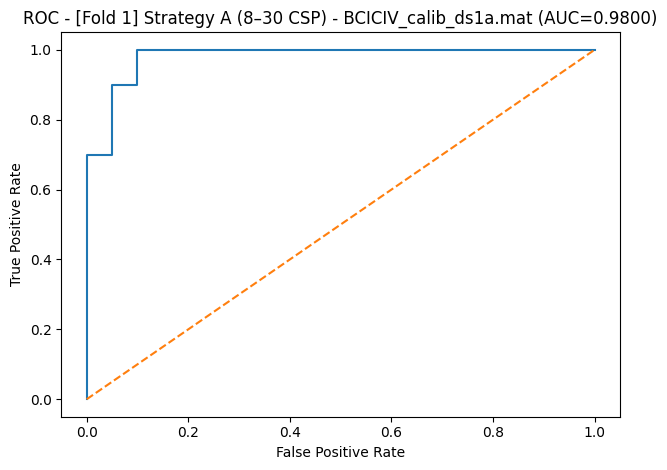


[Fold 1] Strategy B (Mu+Beta CSP concat) - BCICIV_calib_ds1a.mat
Best params: {'svc__C': 10, 'svc__gamma': 0.01}
Accuracy: 0.925
Confusion matrix:
 [[19  1]
 [ 2 18]]
              precision    recall  f1-score   support

           0     0.9048    0.9500    0.9268        20
           1     0.9474    0.9000    0.9231        20

    accuracy                         0.9250        40
   macro avg     0.9261    0.9250    0.9250        40
weighted avg     0.9261    0.9250    0.9250        40


[Fold 2] Strategy A (8–30 CSP) - BCICIV_calib_ds1a.mat
Best params: {'svc__C': 1, 'svc__gamma': 0.01}
Accuracy: 0.9
Confusion matrix:
 [[19  1]
 [ 3 17]]
              precision    recall  f1-score   support

           0     0.8636    0.9500    0.9048        20
           1     0.9444    0.8500    0.8947        20

    accuracy                         0.9000        40
   macro avg     0.9040    0.9000    0.8997        40
weighted avg     0.9040    0.9000    0.8997        40


[Fold 2] Strategy B (M

In [63]:
res_a = evaluate_one_file("BCICIV_calib_ds1a.mat", n_splits=5, plot_roc_first_fold=True)
res_c = evaluate_one_file("BCICIV_calib_ds1c.mat", n_splits=5, plot_roc_first_fold=False)

avg_A = (res_a["A_mean"] + res_c["A_mean"]) / 2.0
avg_B = (res_a["B_mean"] + res_c["B_mean"]) / 2.0

print("\n" + "#"*80)
print("COMPETITION METRIC (Average Accuracy across ds1a & ds1c)")
print("#"*80)
print(f"Strategy A (8–30 CSP): {avg_A:.4f}")
print(f"Strategy B (Mu+Beta CSP concat): {avg_B:.4f}")

best = "A (8–30)" if avg_A >= avg_B else "B (Mu+Beta concat)"
print(f"Best strategy by average accuracy: {best}")
print("#"*80)